# 3 Days of RAG

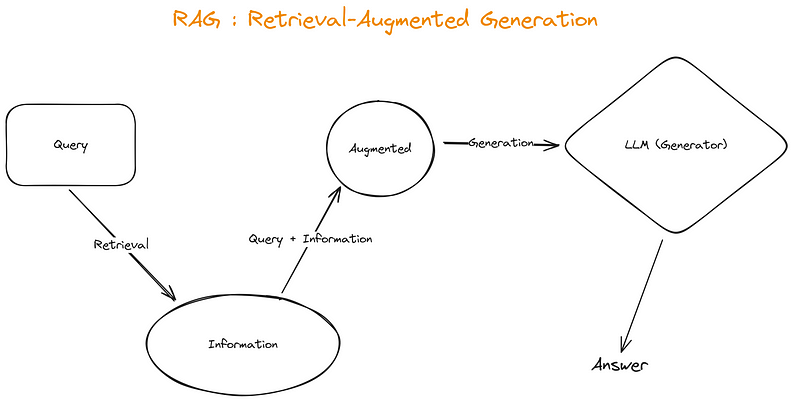

After launch of ChatGPT, you might have heard RAG a lot. Using this method we provide additional information to our LLM model for better query specific generation. We can use our private data to get better results.

RAG stands for Retrieval-Augmented Generation.

We are going to study it in detail and build some applications. Please have a look at above diagram. We are going to look into each stage one by one and implement it in python.

## Query

We can't control user queries. And we shouldn't. So there is not much we can do here. One thing though we can develop a nice UI for better user experience.

## Retrieval

In simple words, in this step we want to pick the most relevant information with respect to our query.   
Now, the information database could be a SQL database, pdfs, search engine results, books, etc. or all.   
Most used way right now is to calculate semantic similarity score between query and information database. And choose top-k results.    
We choose the closet text in meaning to the query and add that to the query and send it to LLM.   
Question right now is how to get semantic similarity score.     
For that, the most used way is a deep learning model trained to create embeddings of a text. It's output will be a vector.   
Let's first build our retrieval part of the solution. It will create vectors of our sample story and store them. Then we will find top-k matches with our query.

OpenAI GPT-4o Mini response without any context:

In [ ]:
# !pip install openai==1.55.3 httpx==0.27.2

In [2]:

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from openai import OpenAI

client = OpenAI()

Without context, no text from story with query

In [4]:
history_openai_format = []
message = f"query: who welcomed Elara?"

history_openai_format.append({"role": "user", "content": message})

response = client.chat.completions.create(model='gpt-4o-mini',
messages= history_openai_format,
temperature=0.2,
seed=1000,
stream=False)

print(response.choices[0].message.content)

Could you please provide more context or specify who or what "Elara" refers to? Elara could refer to a character in a story, a celestial body, or something else entirely. This will help me give you a more accurate answer.


Of course it will fail to answer. The story is private. We need to pass relevant part of the story in the prompt as context.

Let's try with context:

With context, first two chapters from the story

In [5]:
context = '''### Title: **The Quantum Navigator**

#### Chapter 1: The Discovery

In the year 2075, the world was a tapestry of advanced technologies and interconnected systems. Cities floated above the clouds, and artificial intelligence governed almost every aspect of human life. Amidst this technological utopia, in a modest laboratory in the heart of New Tokyo, Dr. Elara Hoshino was on the verge of a groundbreaking discovery.

Dr. Hoshino was a quantum physicist, a genius whose work had already revolutionized the field of quantum mechanics. Her current project was a mysterious device she called the "Quantum Navigator." It was designed to manipulate the fabric of spacetime, allowing instantaneous travel between any two points in the universe. The concept was theoretical, but Elara had spent years perfecting the mathematics and technology behind it.

On a foggy evening, as Elara meticulously calibrated the Navigator, a soft hum filled the room. The air around the device shimmered, and a swirling vortex of light appeared. Her heart raced as she realized the Navigator was operational. She cautiously approached the vortex, a mixture of fear and exhilaration coursing through her veins. With a deep breath, she stepped into the light.

#### Chapter 2: The Other Side

Elara emerged on the other side, not in a distant part of Earth but on a completely different planet. She found herself in a lush, alien jungle, with towering trees that glowed faintly in the twilight. The air was thick with the scent of unknown flora, and the sky was a deep indigo, dotted with unfamiliar constellations.

As she marveled at the beauty of this alien world, she noticed movement in the underbrush. A group of tall, slender beings with translucent skin and luminescent eyes emerged. They communicated through a series of melodic tones, which Elara's universal translator quickly deciphered. The beings were the Lumarians, an ancient race with a deep understanding of the cosmos.

The Lumarians welcomed Elara, intrigued by her arrival. They revealed that they had been aware of Earth's existence for millennia but had chosen to observe from afar. The Lumarians were peaceful and possessed advanced knowledge of quantum travel. They had long ago developed their own version of the Quantum Navigator, which they used to explore the universe and gather knowledge.
'''

In [6]:
history_openai_format = []
message = f"context: {context}, query: who welcomed Elara?"

history_openai_format.append({"role": "user", "content": message})

response = client.chat.completions.create(model='gpt-4o-mini',
messages= history_openai_format,
temperature=0.2,
seed=1000,
stream=False)

In [7]:
response.choices[0].message.content

'Elara was welcomed by the Lumarians, an ancient race with a deep understanding of the cosmos.'

## Create Embeddings

We pass whole text as context, but in practice it will cost us a lot tokens and it will not be practical and will not give good results for very large text like books, etc. So we need to find only relevant text from this and pass that as context in our query to LLM.

In [8]:
all_context = []

In [9]:
with open('story.txt', 'r') as file:
    for f in file.readlines():
        if f != '\n' and f != '\r':
            all_s = f.split('. ')
            all_context.extend(all_s)

In [10]:
len(all_context)

73

In [11]:
all_context[11]

'The air around the device shimmered, and a swirling vortex of light appeared'

In [1]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F


#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)


def create_embedding(text : list):


  # Load model from HuggingFace Hub
  tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
  model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')#.to('cuda')

  # Tokenize sentences
  encoded_input = tokenizer(text, padding=True, truncation=True, return_tensors='pt')

  # Compute token embeddings
  with torch.no_grad():
      model_output = model(**encoded_input)#.to('cuda'))

  # Perform pooling
  sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

  # Normalize embeddings
  sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
  return sentence_embeddings


/home/karan/miniconda3/envs/py39_pytorch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def text_file_to_emb(filename: str):
  '''
  Reads content from text file and divide it in chunks and then create embeddings for them.
  '''
  all_context = []
  with open(filename, 'r') as file:
    for f in file.readlines():
        if f != '\n' and f != '\r':
            all_s = f.split('. ')
            all_context.extend(all_s)

  return create_embedding(all_context)




In [3]:
all_emb = text_file_to_emb('story.txt')

2025-01-13 11:22:45.983484: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-13 11:22:46.210524: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-13 11:22:46.903820: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
all_emb_np = all_emb.cpu().detach().numpy()

In [5]:
import numpy as np

def cosine_similarity(matrix1, matrix2):
    """
    Calculate cosine similarity between two matrices, handling arbitrary shapes.

    Parameters:
    - matrix1: numpy array of shape (m, n)
    - matrix2: numpy array of shape (k, n)

    Returns:
    - similarities: numpy array of shape (m, k) containing cosine similarities
    """
    # Ensure the number of columns (features) matches
    if matrix1.shape[1] != matrix2.shape[1]:
        raise ValueError("The number of columns in matrix1 and matrix2 must match.")

    # Compute the dot product
    dot_product = np.dot(matrix1, matrix2.T)  # Shape: (m, k)

    # Compute the norm of each row in matrix1 and matrix2
    norm_matrix1 = np.linalg.norm(matrix1, axis=1, keepdims=True)  # Shape: (m, 1)
    norm_matrix2 = np.linalg.norm(matrix2, axis=1, keepdims=True)  # Shape: (k, 1)

    # Compute cosine similarity
    similarities = dot_product / (norm_matrix1 * norm_matrix2.T + 1e-10)  # Shape: (m, k)

    return similarities

In [27]:
all_emb_np.shape

(73, 384)

In [33]:
%%timeit
all_sim = cosine_similarity(all_emb_np[0].reshape(1,-1), all_emb_np[0].reshape(1,-1))

6.35 µs ± 62.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [25]:
%%timeit
all_sim = cosine_similarity(all_emb_np, all_emb_np[0].reshape(1,-1))

90.5 µs ± 9.17 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [34]:
all_sim.shape

(1, 1)

In [17]:
k = 5

In [24]:
top_k_indices = np.argsort(all_sim.flatten())[-k:][::-1]

In [12]:
np.argmax(all_sim, axis=0)

array([0])

As our context is smaller, what if we have a very large text content.